In [ ]:
import pandas as pd

In [ ]:
df_men = pd.read_csv(r'c:\Users\met00546\Downloads\ebay_mens_perfume.csv')
df_women = pd.read_csv(r'c:\Users\met00546\Downloads\ebay_womens_perfume.csv')
print(df_men.head())
print(df_women.head())
                     

In [ ]:
df_men.shape
df_women.shape  

In [ ]:
df_men['sex'] = 'men'
df_women['sex'] = 'women'

In [ ]:
df= pd.concat([df_men,df_women], ignore_index=True)
df.columns

In [ ]:
print(df.describe())

In [ ]:
print(df.info())

In [ ]:
df.shape

In [ ]:
df.isnull().sum()

In [ ]:
df = df.drop(columns=['availableText'])

In [ ]:
df.drop(columns=['priceWithCurrency'], inplace=True)


In [ ]:
# 1 Convertir la colonne en string pour pouvoir utiliser .str
df['lastUpdated'] = df['lastUpdated'].astype(str)

# 2 Supprimer les timezone comme PDT, EST, etc.
df['lastUpdated'] = pd.to_datetime(
    df['lastUpdated'].str.replace(r' [A-Z]{3}$','', regex=True),
    errors='coerce'
)

In [ ]:
median_date = df['lastUpdated'].median()
df['lastUpdated'] = df['lastUpdated'].fillna(median_date)

In [ ]:
df = df.fillna({
    'brand': 'Unknown',
    'type': 'Unknown',
    'available': 0,
    'sold': 0,
})

In [ ]:
# Liste des états US
us_states = {
    'Alabama','Alaska','Arizona','Arkansas','California','Colorado','Connecticut',
    'Delaware','Florida','Georgia','Hawaii','Idaho','Illinois','Indiana','Iowa',
    'Kansas','Kentucky','Louisiana','Maine','Maryland','Massachusetts','Michigan',
    'Minnesota','Mississippi','Missouri','Montana','Nebraska','Nevada','New Hampshire',
    'New Jersey','New Mexico','New York','North Carolina','North Dakota','Ohio',
    'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina','South Dakota',
    'Tennessee','Texas','Utah','Vermont','Virginia','Washington','West Virginia',
    'Wisconsin','Wyoming','District of Columbia'
}

# Fonction pour extraire le State
def extract_state_from_location(loc):
    for state in us_states:
        if state.lower() in loc.lower():  # ignore la casse
            return state
    return None  # si aucun état trouvé

# Appliquer la fonction et créer une nouvelle colonne State
df['State'] = df['itemLocation'].apply(extract_state_from_location)

# Supprimer les lignes où aucun état n’est trouvé
df = df[df['State'].notna()].copy()

# Vérifier le résultat
print(df[['itemLocation','State']].to_string())

In [ ]:
df.drop(columns=['itemLocation'], inplace=True)

In [ ]:
print(df.info())

In [ ]:
df['brand'] = df['brand'].str.strip().str.title()
brand_mapping = {
    'dolce&gabbana': 'dolce & gabbana',
    'dolce & gabbana': 'dolce & gabbana',
    '~ dolce & gabbana ~': 'dolce & gabbana',
    'montblanc': 'mont blanc',
    'mont blanc': 'mont blanc',
    'ysl': 'yves saint laurent',
    'yves saint laurent': 'yves saint laurent',
    'hugo boss': 'hugo boss',
    'gianni versace': 'versace',
    'christian dior': 'dior',
    'dior': 'dior',
    'c.k': 'calvin klein',
    'calvin klein': 'calvin klein',

    'estee lauder': 'estée lauder',
    'estée lauder': 'estée lauder',

    'hermes': 'hermès',
    'hermès': 'hermès',

    'giorgio arm.ani': 'giorgio armani',
    'giorgio armani': 'giorgio armani',

    'roja dove': 'roja',
    'roja': 'roja',

    'mercedes-benz': 'mercedes benz',
    'mercedes benz': 'mercedes benz',

    'victor & rolf': 'viktor & rolf',
    'viktor & rolf': 'viktor & rolf',

    'maison martin margiela': 'maison margiela',
    'maison margiela': 'maison margiela',

    'michael malul london': 'michael malul',
    'michael malul gents scents': 'michael malul',
    'michael malul': 'michael malul'
}
df['brand'] = df['brand'].replace(brand_mapping)

print(df['brand'].unique())
print(f"Nombre de marques distinctes après mappage : {df['brand'].nunique()}")

In [ ]:
not_brands = {
    'as photos','as picture show','as picture shown','as show','as showed','as shown',
    'assorted','does not apply','multiple brands','unbranded','limited edition',
    'designer series','classic brands','cologne','fragrance','luxury','pheromones',
    'topshelf'
}

df['brand'] = df['brand'].apply(
    lambda x: 'unknown' if x.lower().strip() in not_brands else x
)


In [ ]:
print(df['brand'].unique())
print(f"Nombre de marques distinctes après mappage : {df['brand'].nunique()}")

In [ ]:
print(((df['brand'].isna()) | (df['brand'].str.strip() == '')).sum())

In [ ]:
df['title'] = df['title'].str.title()
import re

df['title_clean'] = df['title'].apply(lambda x: re.sub(r'[\*\!]+','', str(x)))


In [ ]:
df.drop(columns=['title'], inplace=True)

In [ ]:
df.rename(columns={'title_clean': 'title'}, inplace=True)


In [ ]:
type_map = {
    # Eau de Toilette
    'Eau De Toillette': 'Eau De Toilette',
    'Edt': 'Eau De Toilette',
    'Edc': 'Cologne',
    'Toilette Spray': 'Eau De Toilette',
    'Eau De Toilette Spray 3.4 Oz': 'Eau De Toilette',
    'Eau De Toilette Intense': 'Eau De Toilette',
    'Eau De Toilette, Spray': 'Eau De Toilette',
    'Eau De Toilette, Cologne Spray': 'Eau De Toilette',

    # Eau de Parfum
    'Eau De Perfume': 'Eau De Parfum',
    'Eau De Parfume': 'Eau De Parfum',
    'Edp': 'Eau De Parfum',
    'Le Parfum': 'Eau De Parfum',
    "L'Eau De Parfum": 'Eau De Parfum',
    'Eau De Parfum Intense': 'Eau De Parfum',
    'Eau De Parfum Supreme': 'Eau De Parfum',
    'Eau De Parfum Spray': 'Eau De Parfum',
    'Eau De Parfum/ Eau De Toilette': 'Eau De Parfum',
    'Eau De Parfum/Perfume': 'Eau De Parfum',
    'Perfume, Eau De Parfum': 'Eau De Parfum',
    'Edp And Parfum': 'Eau De Parfum',
    'Extract Parfum': 'Parfum',

    # Parfum
    'Parfum Intense': 'Parfum',
    'Extrait De Parfum': 'Parfum',
    'Perfume': 'Parfum',
    'Perfume Oil': 'Parfum',
    'Oil Perfume': 'Parfum',

    # Cologne
    'Cologne Spray': 'Cologne',
    'Eau De Cologne': 'Cologne',
    'Eau De Cologne Spray': 'Cologne',
    'Fine Cologne': 'Cologne',
    'Jo Malone Cologne Intense Spray': 'Cologne',

    # Oils
    'Oil': 'Oil',
    'Body Oil': 'Oil',
    'Bath Oil': 'Oil',
    'Scented Oils': 'Oil',
    'Shimmering Body Oil': 'Oil',
    'Concentrated Uncut Pure Body Oil': 'Oil',

    # Mist / Spray
    'Body Spray': 'Mist',
    'Body Mist': 'Mist',
    'Fragrance Mist': 'Mist',
    'Fine Fragrance Mist': 'Mist',
    'Perfume Fragrance Mist': 'Mist',
    'Fragrance Body Mist': 'Mist',
    'Mist': 'Mist',

    # Deodorant / Aftershave
    'Deodorant': 'Deodorant',
    'Deodorant Body Spray': 'Deodorant',
    'Deodorant Stick': 'Deodorant',
    'Aftershave': 'Aftershave',

    # Gift / Sets
    'Gift Sets': 'Gift Set',
    'Perfume Gift Sets': 'Gift Set',
    'Discovery Set': 'Gift Set',
    '3 Pc': 'Gift Set',
    'Eau De Parfum 2 Pcs Set': 'Gift Set',
    'Eau De Parfum 3 Pcs Set': 'Gift Set',

    # Body / Other products
    'Body Lotion': 'Body Product',
    'Lotion': 'Body Product',
    'Cream': 'Body Product',
    'Body Powder': 'Body Product',
    'Hair Perfume': 'Body Product',
    'Skin_Moisturizer': 'Body Product',
    'Sensuous Body Moisturizer': 'Body Product',

    # Invalid / noise
    'Does Not Apply': 'Unknown',
    'Unscented': 'Unknown',
    'Unknown': 'Unknown',
    'Asst': 'Unknown',
    'Beauty': 'Unknown',
    '1': 'Unknown'
}

df['type_clean'] = (
    df['type']
    .str.strip()
    .replace(type_map))


df['type_clean'] = df['type_clean'].replace(
    ['Various', 'Assorted', 'Y'], 'Unknown'
)

In [ ]:

cleanup_map = {
    'Fragrances': 'Parfum',
    'Fragrance & Perfume': 'Parfum',
    'Pheromone': 'Parfum',
    'Elixir': 'Parfum',
    'Elixir De Parfum': 'Parfum',
    'Esprit De Parfum': 'Parfum',

    'Fragrance Oil': 'Oil',
    'Fragrance Rolling Ball': 'Oil',
    'Roll On': 'Oil',

    'Splash-On': 'Cologne',
    'Spray': 'Cologne',
    'Eau De Parfum, Spray': 'Eau De Parfum',

    'Shimmer': 'Body Product',

    'Car Air Freshener': 'Unknown',
    'De Nuit': 'Unknown',
    'Pink Sugar': 'Unknown',
    'Eau De Toilette, Eau De Parfum, Eau De Parfum Intense': 'Unknown',
    'Parfum, Lotion, Gloss And Blush': 'Unknown',
    'Eau De Parfum Spray (Unisex Tester) 3.4 Oz': 'Eau De Parfum'
}


df['type_clean'] = (
    df['type']
    .str.strip()
    .replace(cleanup_map)
)

df['type_clean'] = df['type_clean'].replace(
    ['Various', 'Assorted', 'Y'], 'Unknown'
)


In [ ]:
df.rename(columns={'type_clean': 'type'}, inplace=True)


In [ ]:
df.columns

In [ ]:
df['type'] = df['type'].str.strip().str.title()

In [ ]:
print(df['type'].unique())
print(f"Nombre de types distinctes après mappage : {df['type'].nunique()}")

In [ ]:
df = df[['brand', 'title', 'type', 'sex','price', 'sold', 'available',
         'lastUpdated',  'State']]
print(df.info())

In [ ]:
df.columns

In [ ]:
%pip install matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

<Figure size 1200x800 with 0 Axes>

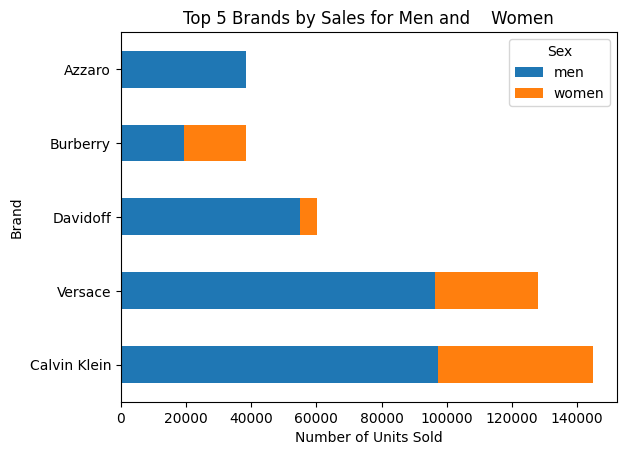

In [56]:
# Agrégation par brand et sex
df_brand_sex = (
    df.groupby(['brand', 'sex'])['sold']
      .sum()
      .unstack(fill_value=0)
)

# Sélection du Top 5 brands (ventes totales)
top5_brands = df_brand_sex.sum(axis=1).sort_values(ascending=False).head(5).index

df_top5 = df_brand_sex.loc[top5_brands]
plt.figure(figsize=(12,8))
df_top5.plot(kind='barh', stacked=True)
plt.title('Top 5 Brands by Sales for Men and    Women')
plt.xlabel('Number of Units Sold')  
plt.ylabel('Brand')
plt.legend(title='Sex')
plt.show()

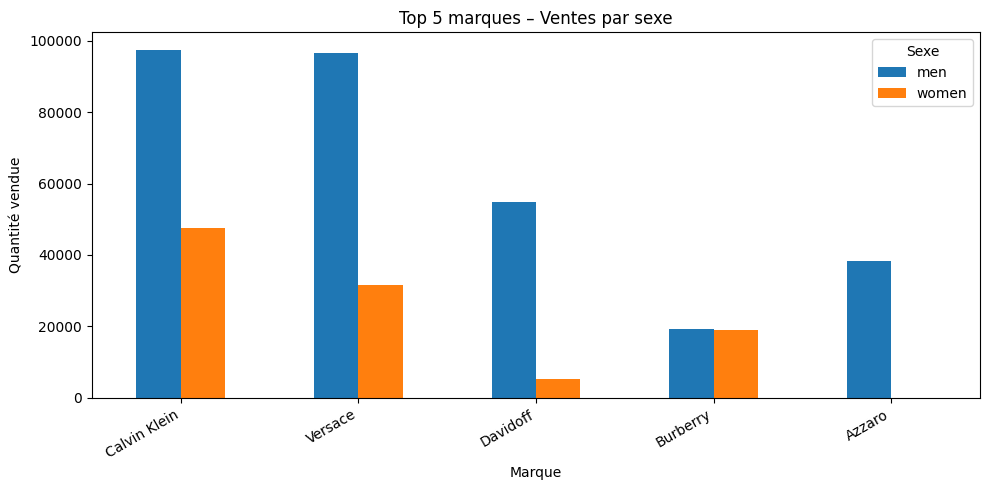

In [57]:
ax = df_top5.plot(
    kind='bar',
    figsize=(10, 5)
)

ax.set_title('Top 5 marques – Ventes par sexe')
ax.set_xlabel('Marque')
ax.set_ylabel('Quantité vendue')
ax.legend(title='Sexe')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


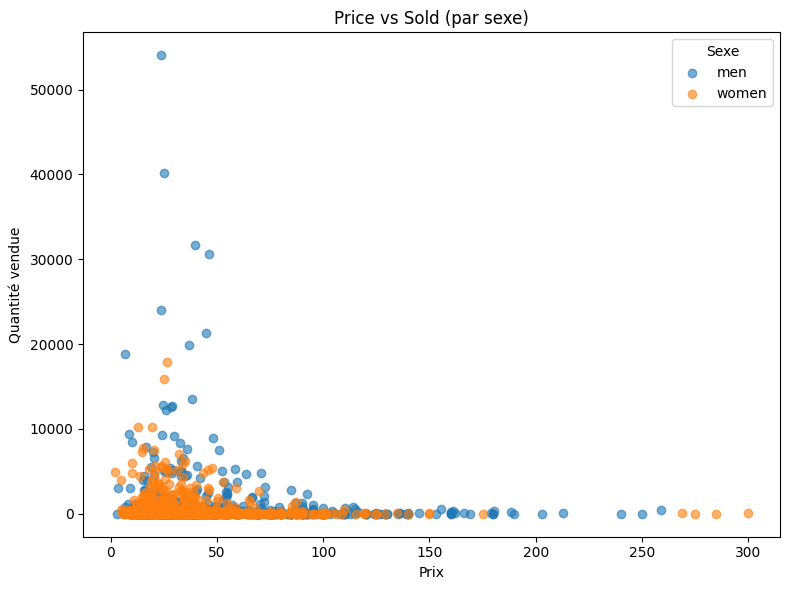

In [58]:
plt.figure(figsize=(8, 6))

for s in df['sex'].unique():
    subset = df[df['sex'] == s]
    plt.scatter(
        subset['price'],
        subset['sold'],
        label=s,
        alpha=0.6
    )

plt.title('Price vs Sold (par sexe)')
plt.xlabel('Prix')
plt.ylabel('Quantité vendue')
plt.legend(title='Sexe')
plt.tight_layout()
plt.show()


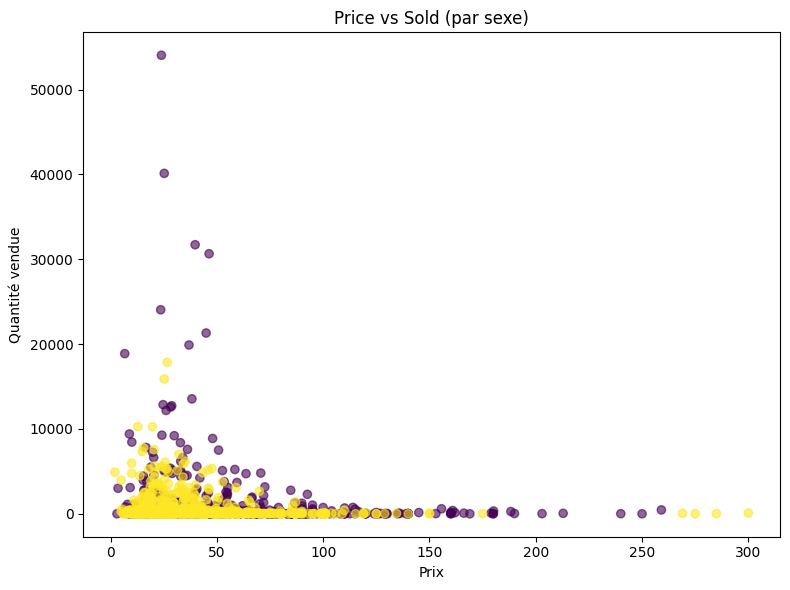

In [59]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['price'],
    df['sold'],
    c=df['sex'].astype('category').cat.codes,
    alpha=0.6
)

plt.title('Price vs Sold (par sexe)')
plt.xlabel('Prix')
plt.ylabel('Quantité vendue')
plt.tight_layout()
plt.show()


In [60]:
%pip install geopandas
import geopandas as gpd

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/22.9 MB 2.4 MB/s eta 0:00:10
   - -------------------------------------- 1.0/22.9 MB 1.9 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/22.9 MB 1.6 MB/s eta 0:00:14
   --- ------------------------------------ 1.8/22.9 MB 1.7 MB/s eta 0:00:13
   --- ------------------------------------ 2.1/22.9 MB 1.8 MB/s eta 0:00:12
   ---- ----------------------------------- 2.6/22.9 MB 1.8 MB/s eta 0:00:12
   ----- ---------------------------------- 2.9/22.9 MB 1.8 MB/s eta 0:00:12
   ----- ---------------------------------- 3.1/22.9 MB 1.6 MB/s eta 0:00:13
   ----- ---------------------------------- 3.1/22.9 MB 1.6 MB/s eta 0:00:13
   ----- ---------------------------------- 3.4/22.9 MB 1.5 MB/s eta 0:00:13
   ------ --


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
df_state_sex = (
    df.groupby(['State', 'sex'])['sold']
      .sum()
      .reset_index()
)

In [63]:
# GeoJSON des états US
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
states = gpd.read_file(url)

# Normaliser les noms
states['name'] = states['name'].str.strip()


In [64]:
# Total sold par State et par sex
df_state_sex = df.groupby(['State', 'sex'])['sold'].sum().reset_index()

# Merge avec la carte
geo_df = states.merge(df_state_sex, left_on='name', right_on='State', how='left')


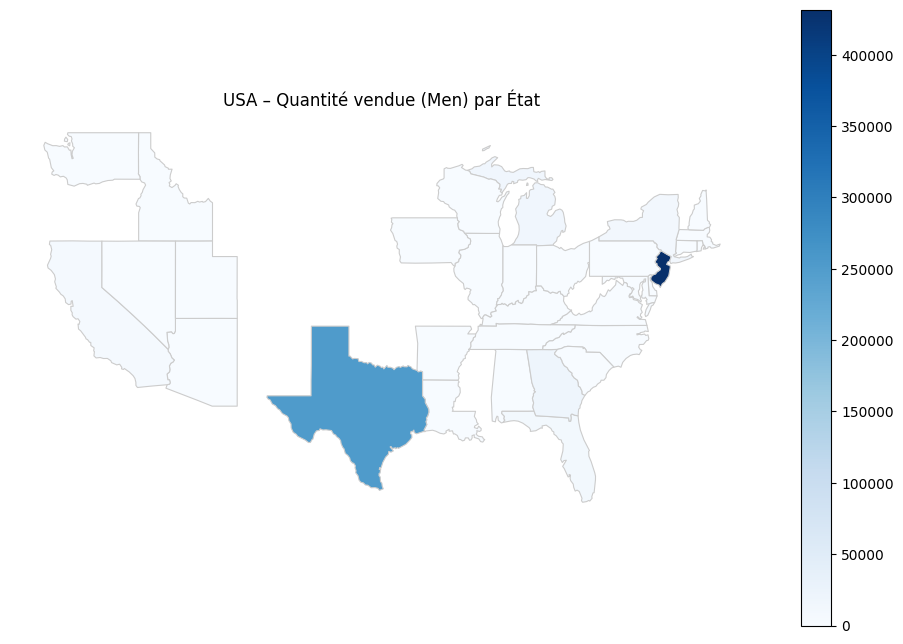

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

geo_df[geo_df['sex'] == 'men'].plot(
    column='sold',
    cmap='Blues',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

ax.set_title('USA – Quantité vendue (Men) par État')
ax.axis('off')
plt.show()


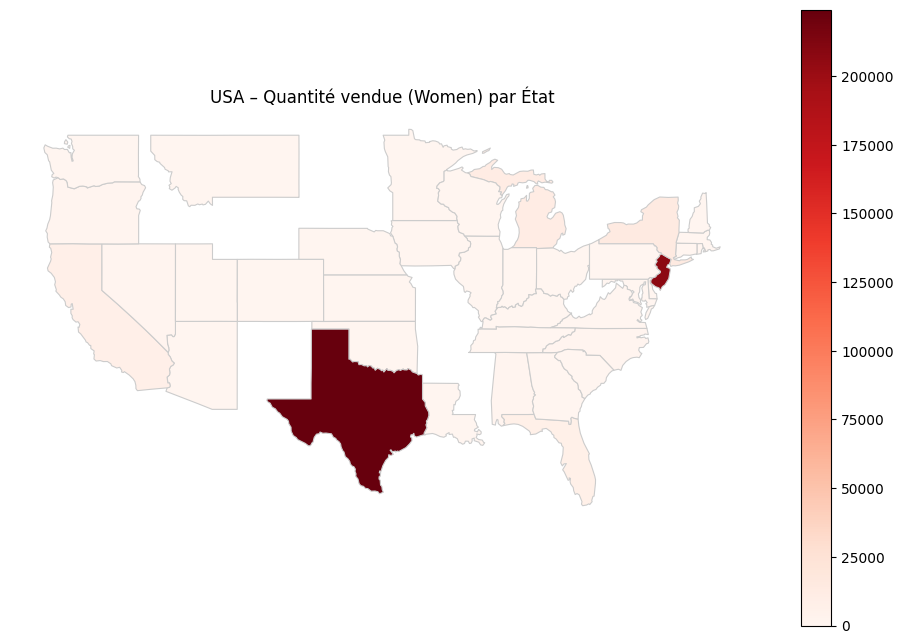

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

geo_df[geo_df['sex'] == 'women'].plot(
    column='sold',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True
)

ax.set_title('USA – Quantité vendue (Women) par État')
ax.axis('off')
plt.show()


In [67]:
# Total sold par State et par sex
df_state_sex = df.groupby(['State', 'sex'])['sold'].sum().reset_index()


In [68]:
# Pour Men
top5_men = df_state_sex[df_state_sex['sex'] == 'men'].sort_values('sold', ascending=False).head(5)

# Pour Women
top5_women = df_state_sex[df_state_sex['sex'] == 'women'].sort_values('sold', ascending=False).head(5)


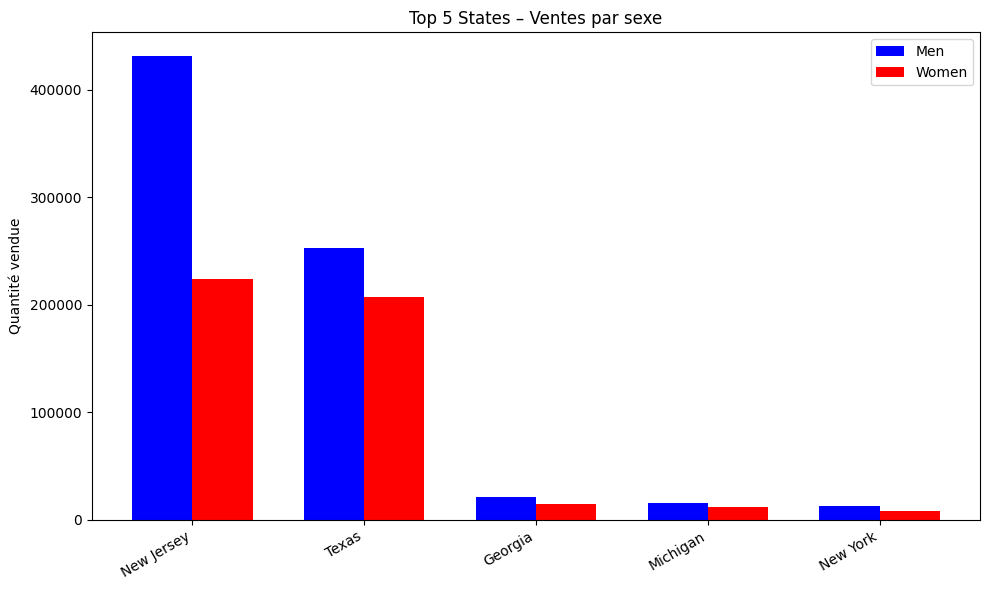

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# États pour chaque sexe
states_men = top5_men['State']
sold_men = top5_men['sold']

states_women = top5_women['State']
sold_women = top5_women['sold']

# Largeur des barres
width = 0.35
x = np.arange(len(states_men))  # position pour Men

fig, ax = plt.subplots(figsize=(10,6))

# Barres Men
ax.bar(x - width/2, sold_men, width, label='Men', color='blue')

# Barres Women (aligné à droite par rapport à Men)
ax.bar(x + width/2, sold_women, width, label='Women', color='red')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(states_men, rotation=30, ha='right')
ax.set_ylabel('Quantité vendue')
ax.set_title('Top 5 States – Ventes par sexe')
ax.legend()

plt.tight_layout()
plt.show()


In [70]:
# Seuils
price_threshold = df['price'].quantile(0.75)
sold_threshold = df['sold'].quantile(0.75)


In [71]:
premium_df = df[
    (df['price'] >= price_threshold) &
    (df['sold'] >= sold_threshold)
]


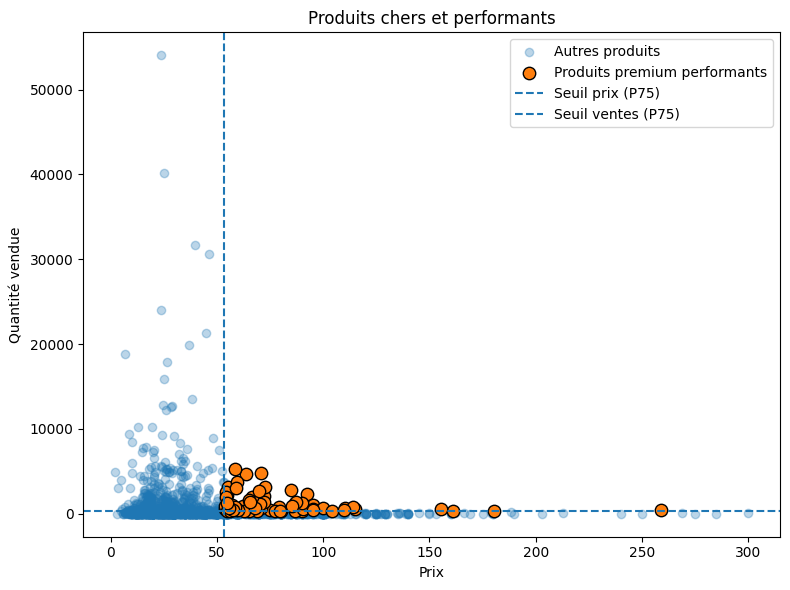

In [72]:
plt.figure(figsize=(8, 6))

# Tous les produits (fond)
plt.scatter(
    df['price'],
    df['sold'],
    alpha=0.3,
    label='Autres produits'
)

# Produits premium performants
plt.scatter(
    premium_df['price'],
    premium_df['sold'],
    label='Produits premium performants',
    edgecolors='black',
    s=80
)

# Lignes de seuil
plt.axvline(price_threshold, linestyle='--', label='Seuil prix (P75)')
plt.axhline(sold_threshold, linestyle='--', label='Seuil ventes (P75)')

plt.title('Produits chers et performants')
plt.xlabel('Prix')
plt.ylabel('Quantité vendue')
plt.legend()
plt.tight_layout()
plt.show()
